Personal project predciting customer churn using ANNS

Phase 1 - import data base and data eda

In [91]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

load data set 

In [92]:
df = pd.read_csv(r'\Users\karam\OneDrive\Desktop\personal project\data\cell2celltrain.csv')
df.head()

,CustomerID,Churn,MonthlyRevenue,MonthlyMinutes,TotalRecurringCharge,DirectorAssistedCalls,OverageMinutes,RoamingCalls,PercChangeMinutes,PercChangeRevenues,DroppedCalls,BlockedCalls,UnansweredCalls,CustomerCareCalls,ThreewayCalls,ReceivedCalls,OutboundCalls,InboundCalls,PeakCallsInOut,OffPeakCallsInOut,DroppedBlockedCalls,CallForwardingCalls,CallWaitingCalls,MonthsInService,UniqueSubs,ActiveSubs,ServiceArea,Handsets,HandsetModels,CurrentEquipmentDays,AgeHH1,AgeHH2,ChildrenInHH,HandsetRefurbished,HandsetWebCapable,TruckOwner,RVOwner,Homeownership,BuysViaMailOrder,RespondsToMailOffers,OptOutMailings,NonUSTravel,OwnsComputer,HasCreditCard,RetentionCalls,RetentionOffersAccepted,NewCellphoneUser,NotNewCellphoneUser,ReferralsMadeBySubscriber,IncomeGroup,OwnsMotorcycle,AdjustmentsToCreditRating,HandsetPrice,MadeCallToRetentionTeam,CreditRating,PrizmCode,Occupation,MaritalStatus
0,3000002,Yes,24.00,219.0,22.0,0.25,0.0,0.0,-157.0,-19.0,0.7,0.7,6.3,0.0,0.0,97.2,0.0,0.0,58.0,24.0,1.3,0.0,0.3,61,2,1,SEAPOR503,2.0,2.0,361.0,62.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,Yes,Yes,1,0,No,No,0,4,No,0,30,Yes,1-Highest,Suburban,Professional,No
1,3000010,Yes,16.99,10.0,17.0,0.00,0.0,0.0,-4.0,0.0,0.3,0.0,2.7,0.0,0.0,0.0,0.0,0.0,5.0,1.0,0.3,0.0,0.0,58,1,1,PITHOM412,2.0,1.0,1504.0,40.0,42.0,Yes,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,Yes,No,0,5,No,0,30,No,4-Medium,Suburban,Professional,Yes
2,3000014,No,38.00,8.0,38.0,0.00,0.0,0.0,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.3,0.0,1.3,3.7,0.0,0.0,0.0,60,1,1,MILMIL414,1.0,1.0,1812.0,26.0,26.0,Yes,No,No,No,No,Unknown,No,No,No,No,No,Yes,0,0,Yes,No,0,6,No,0,Unknown,No,3-Good,Town,Crafts,Yes
3,3000022,No,82.28,1312.0,75.0,1.24,0.0,0.0,157.0,8.1,52.0,7.7,76.0,4.3,1.3,200.3,370.3,147.0,555.7,303.7,59.7,0.0,22.7,59,2,2,PITHOM412,9.0,4.0,458.0,30.0,0.0,No,No,Yes,No,No,Known,Yes,Yes,No,No,No,Yes,0,0,Yes,No,0,6,No,0,10,No,4-Medium,Other,Other,No
4,3000026,Yes,17.14,0.0,17.0,0.00,0.0,0.0,0.0,-0.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53,2,2,OKCTUL918,4.0,3.0,852.0,46.0,54.0,No,No,No,No,No,Known,Yes,Yes,No,No,Yes,Yes,0,0,No,Yes,0,9,No,1,10,No,1-Highest,Other,Professional,Yes


get the categroical collums 

In [93]:
cat_cols = [col for col in df.columns if df[col].dtype=='object']
cat_cols

['Churn',
 'ServiceArea',
 'ChildrenInHH',
 'HandsetRefurbished',
 'HandsetWebCapable',
 'TruckOwner',
 'RVOwner',
 'Homeownership',
 'BuysViaMailOrder',
 'RespondsToMailOffers',
 'OptOutMailings',
 'NonUSTravel',
 'OwnsComputer',
 'HasCreditCard',
 'NewCellphoneUser',
 'NotNewCellphoneUser',
 'OwnsMotorcycle',
 'HandsetPrice',
 'MadeCallToRetentionTeam',
 'CreditRating',
 'PrizmCode',
 'Occupation',
 'MaritalStatus']

In [94]:
# get the datsets informoation 
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51047 entries, 0 to 51046
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 51047 non-null  int64  
 1   Churn                      51047 non-null  object 
 2   MonthlyRevenue             50891 non-null  float64
 3   MonthlyMinutes             50891 non-null  float64
 4   TotalRecurringCharge       50891 non-null  float64
 5   DirectorAssistedCalls      50891 non-null  float64
 6   OverageMinutes             50891 non-null  float64
 7   RoamingCalls               50891 non-null  float64
 8   PercChangeMinutes          50680 non-null  float64
 9   PercChangeRevenues         50680 non-null  float64
 10  DroppedCalls               51047 non-null  float64
 11  BlockedCalls               51047 non-null  float64
 12  UnansweredCalls            51047 non-null  float64
 13  CustomerCareCalls          51047 non-null  flo

In [95]:
df.isnull().sum()

CustomerID                     0
Churn                          0
MonthlyRevenue               156
MonthlyMinutes               156
TotalRecurringCharge         156
DirectorAssistedCalls        156
OverageMinutes               156
RoamingCalls                 156
PercChangeMinutes            367
PercChangeRevenues           367
DroppedCalls                   0
BlockedCalls                   0
UnansweredCalls                0
CustomerCareCalls              0
ThreewayCalls                  0
ReceivedCalls                  0
OutboundCalls                  0
InboundCalls                   0
PeakCallsInOut                 0
OffPeakCallsInOut              0
DroppedBlockedCalls            0
CallForwardingCalls            0
CallWaitingCalls               0
MonthsInService                0
UniqueSubs                     0
ActiveSubs                     0
ServiceArea                   24
Handsets                       1
HandsetModels                  1
CurrentEquipmentDays           1
AgeHH1    

we have several collumns with missing data we now need to decide which collumns to drop as thier useless to us and rows to drop due to missing data and avereges to add for rows that need it -- collums like customer id are usless to us so we can drop them collums like monthyly rev, mins ,total rec charge , director assited calls ,overage minutes and roaming calls are critical data so dropping would be ideal as replacing this data could add unesscary noise in out predicition models. service area we drop as too spefic to guess , collums with small amount of missing data we drop as 1 out of 51,000 isnt particualr impactful. percchange mins and rev we will fill with 0s as missing values usally mean no change recorded / new customers and for age since thiers alot of missing data we can use median to replace it mitgating the loss of the data 

In [96]:

df = df.drop(['CustomerID'], axis=1)

df = df.dropna(subset=['MonthlyRevenue', 'MonthlyMinutes', 'ServiceArea', 'Handsets', 'CurrentEquipmentDays'])


df['PercChangeMinutes'] = df['PercChangeMinutes'].fillna(0)
df['PercChangeRevenues'] = df['PercChangeRevenues'].fillna(0)


df['AgeHH1'] = df['AgeHH1'].fillna(df['AgeHH1'].median())
df['AgeHH2'] = df['AgeHH2'].fillna(df['AgeHH2'].median())


missing_data = df.isnull().sum()
print(f"Total mssing data left  :{missing_data}")
print(f"new dataframe shape :{df.shape}")

Total mssing data left  :Churn                        0
MonthlyRevenue               0
MonthlyMinutes               0
TotalRecurringCharge         0
DirectorAssistedCalls        0
OverageMinutes               0
RoamingCalls                 0
PercChangeMinutes            0
PercChangeRevenues           0
DroppedCalls                 0
BlockedCalls                 0
UnansweredCalls              0
CustomerCareCalls            0
ThreewayCalls                0
ReceivedCalls                0
OutboundCalls                0
InboundCalls                 0
PeakCallsInOut               0
OffPeakCallsInOut            0
DroppedBlockedCalls          0
CallForwardingCalls          0
CallWaitingCalls             0
MonthsInService              0
UniqueSubs                   0
ActiveSubs                   0
ServiceArea                  0
Handsets                     0
HandsetModels                0
CurrentEquipmentDays         0
AgeHH1                       0
AgeHH2                       0
ChildrenInHH  

implements graphs needed to analyse what aour colums mean for business and how they relate to churn EDA

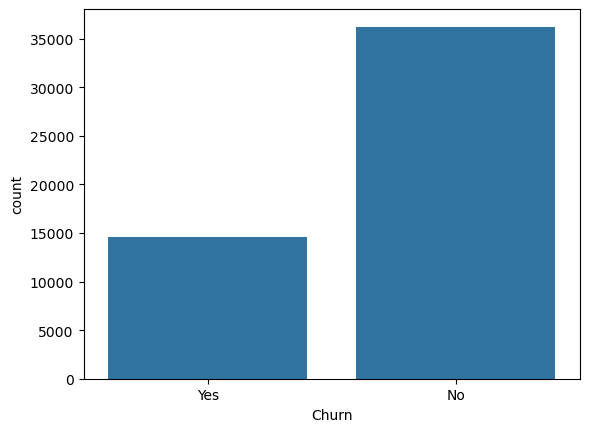

In [99]:
sns.countplot(x='Churn' , data=df);


as we can see our data is not balanced we would need to implement some kind of balancing ie smote etc to increanse the number of yes has chruned 

now we need to turn our object data too numbers ,for object data with 2choices well use label encoding for multiply well use one hot encoding and for ones with too many choices we will just drop the collum. we drop severice area as the choices for this is endless and we identify all object data

In [73]:

df = df.drop(['ServiceArea'], axis=1)

object_cols = df.select_dtypes(include=['object']).columns
print(list(object_cols))

['Churn', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'Homeownership', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'NotNewCellphoneUser', 'OwnsMotorcycle', 'HandsetPrice', 'MadeCallToRetentionTeam', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']


will drop not new cellphone user as same results as new cellphone users and use one hot on non binary data

In [74]:
multi_cols_check = ['Homeownership', 'HandsetPrice', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus','Churn', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 'NewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam']

for col in multi_cols_check:
    print(f"{col}: {df[col].unique()}")

Homeownership: ['Known' 'Unknown']
HandsetPrice: ['30' 'Unknown' '10' '80' '150' '300' '40' '200' '100' '130' '60' '400'
 '240' '250' '180' '500']
CreditRating: ['1-Highest' '4-Medium' '3-Good' '6-VeryLow' '2-High' '5-Low' '7-Lowest']
PrizmCode: ['Suburban' 'Town' 'Other' 'Rural']
Occupation: ['Professional' 'Crafts' 'Other' 'Self' 'Retired' 'Homemaker' 'Clerical'
 'Student']
MaritalStatus: ['No' 'Yes' 'Unknown']
Churn: ['Yes' 'No']
ChildrenInHH: ['No' 'Yes']
HandsetRefurbished: ['No' 'Yes']
HandsetWebCapable: ['Yes' 'No']
TruckOwner: ['No' 'Yes']
RVOwner: ['No' 'Yes']
BuysViaMailOrder: ['Yes' 'No']
RespondsToMailOffers: ['Yes' 'No']
OptOutMailings: ['No' 'Yes']
NonUSTravel: ['No' 'Yes']
OwnsComputer: ['Yes' 'No']
HasCreditCard: ['Yes' 'No']
NewCellphoneUser: ['No' 'Yes']
OwnsMotorcycle: ['No' 'Yes']
MadeCallToRetentionTeam: ['Yes' 'No']


In [75]:
from sklearn.preprocessing import LabelEncoder

binary_cols = [
    'Churn', 'ChildrenInHH', 'HandsetRefurbished', 'HandsetWebCapable', 
    'TruckOwner', 'RVOwner', 'BuysViaMailOrder', 'RespondsToMailOffers', 
    'OptOutMailings', 'NonUSTravel', 'OwnsComputer', 'HasCreditCard', 
    'NewCellphoneUser', 'OwnsMotorcycle', 'MadeCallToRetentionTeam', 'Homeownership'
]

multi_cols = ['HandsetPrice', 'CreditRating', 'PrizmCode', 'Occupation', 'MaritalStatus']

lab = LabelEncoder()
for col in binary_cols:
    df[col] = lab.fit_transform(df[col])

# drop first to prebemt linear and ann from poteinally getting confused and makes data set smaller if we know 2 categroies we can work out the 3rd so ones not needed 
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)

print(f"no of collums {df.shape[1]}")

no of collums 84
